# Exploração operacional do Airbnb Open Data

Esta análise é uma primeira leitura operacional da fonte pública `arianazmoudeh/airbnbopendata`, sem antecipar uma decisão específica. O objetivo é entender a cobertura do inventário, a qualidade dos campos, diferenças entre tipos de imóvel e regiões, disponibilidade e sinais de interação dos hóspedes.

Os resultados devem ser usados como diagnóstico inicial. A fonte contém campos com inconsistências que precisam ser tratados antes de apoiar precificação, metas ou decisões de operação.

## Como a fonte pode ser carregada de forma reproduzível?
A fonte é baixada pelo `kagglehub`; nenhum arquivo bruto é salvo no repositório.

In [1]:
%pip install -q "kagglehub[pandas-datasets]"

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.1f}".format

In [3]:
COR_PRIMARIA = "#0072B2"
COR_SECUNDARIA = "#94A3B8"
COR_DESTAQUE = "#E69F00"
COR_EIXO = "#B0B7C3"
COR_TEXTO = "#334155"
PALETA = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00"]
plt.rcParams.update({"figure.figsize": (10, 6), "figure.dpi": 110, "font.size": 11,
    "text.color": COR_TEXTO, "axes.titlesize": 15, "axes.titleweight": "bold",
    "axes.edgecolor": COR_EIXO, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "xtick.color": COR_EIXO, "ytick.color": COR_EIXO})

def reais(v):
    return f"R$ {v:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

In [4]:
import kagglehub

dataset_dir = Path(kagglehub.dataset_download("arianazmoudeh/airbnbopendata"))
csv_path = next(dataset_dir.glob("*.csv"))
df = pd.read_csv(csv_path, low_memory=False)
print(f"Arquivo: {csv_path.name} | Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}")

Arquivo: Airbnb_Open_Data.csv | Linhas: 102,599 | Colunas: 26


## Os dados foram lidos corretamente?
A checagem confirma tamanho, rótulos, tipos e uma amostra curta antes de qualquer transformação.

In [5]:
colunas_preview = ["id", "NAME", "neighbourhood group", "room type", "price", "availability 365"]
display(df[colunas_preview].head().style.hide(axis="index"))
display(df.dtypes.astype("string").to_frame("tipo"))
print("Dimensão:", df.shape)

id,NAME,neighbourhood group,room type,price,availability 365
1001254,Clean & quiet apt home by the park,Brooklyn,Private room,$966,286.000000
1002102,Skylit Midtown Castle,Manhattan,Entire home/apt,$142,228.000000
1002403,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,$620,352.000000
1002755,nan,Brooklyn,Entire home/apt,$368,322.000000
1003689,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,$204,289.000000


,tipo
id,int64
NAME,str
host id,int64
host_identity_verified,str
host name,str
neighbourhood group,str
neighbourhood,str
lat,float64
long,float64
country,str


Dimensão: (102599, 26)


**Leitura confirmada:** o separador e os rótulos foram reconhecidos, mas `price` e `service fee` chegaram como texto. Essas colunas precisam ser convertidas antes de qualquer comparação financeira.

## Quais ajustes tornam os campos comparáveis?
Vou converter preço, taxa de serviço e data da última avaliação sem sobrescrever os campos originais.

In [6]:
df = df.copy()
for coluna in ["price", "service fee"]:
    df[f"{coluna}_num"] = pd.to_numeric(
        df[coluna].astype("string").str.replace(r"[$,]", "", regex=True), errors="coerce"
    )
df["last_review_dt"] = pd.to_datetime(df["last review"], errors="coerce")
display(df[["price", "price_num", "service fee", "service fee_num", "last review", "last_review_dt"]].head().style.hide(axis="index"))

price,price_num,service fee,service fee_num,last review,last_review_dt
$966,966,$193,193,10/19/2021,2021-10-19 00:00:00
$142,142,$28,28,5/21/2022,2022-05-21 00:00:00
$620,620,$124,124,nan,NaT
$368,368,$74,74,7/5/2019,2019-07-05 00:00:00
$204,204,$41,41,11/19/2018,2018-11-19 00:00:00


A conversão cria campos numéricos e uma data analisável, mantendo a origem para auditoria. O próximo passo é medir o quanto os problemas de qualidade podem afetar a leitura.

## Quais problemas de qualidade precisam ser considerados na operação?
A tabela mostra volume, duplicidade e campos ausentes; também separa valores fora dos limites operacionais esperados.

In [7]:
quality = pd.DataFrame({
    "indicador": ["linhas", "ids duplicados", "preço ausente", "disponibilidade ausente", "disponibilidade fora de 0–365", "data futura após 2024"],
    "quantidade": [len(df), df["id"].duplicated().sum(), df["price_num"].isna().sum(), df["availability 365"].isna().sum(), ((df["availability 365"] < 0) | (df["availability 365"] > 365)).sum(), (df["last_review_dt"] > "2024-12-31").sum()]
})
display(quality.style.hide(axis="index"))
print("Campos ausentes mais frequentes:")
display(df.isna().mean().mul(100).sort_values(ascending=False).head(8).round(1).to_frame("percentual"))

indicador,quantidade
linhas,102599
ids duplicados,541
preço ausente,247
disponibilidade ausente,448
disponibilidade fora de 0–365,3214
data futura após 2024,4


Campos ausentes mais frequentes:


,percentual
license,100.0
house_rules,50.8
last_review_dt,15.5
last review,15.5
reviews per month,15.5
country,0.5
availability 365,0.4
minimum nights,0.4


**Leitura crítica:** o inventário não deve ser usado diretamente para metas. Duplicidades, disponibilidade impossível, datas futuras e o campo `license` quase todo vazio indicam necessidade de uma etapa de saneamento antes de decisões financeiras ou de capacidade.

## Como o inventário está distribuído por tipo de imóvel?
A comparação mostra o tamanho de cada oferta, com rótulos diretamente nas barras.

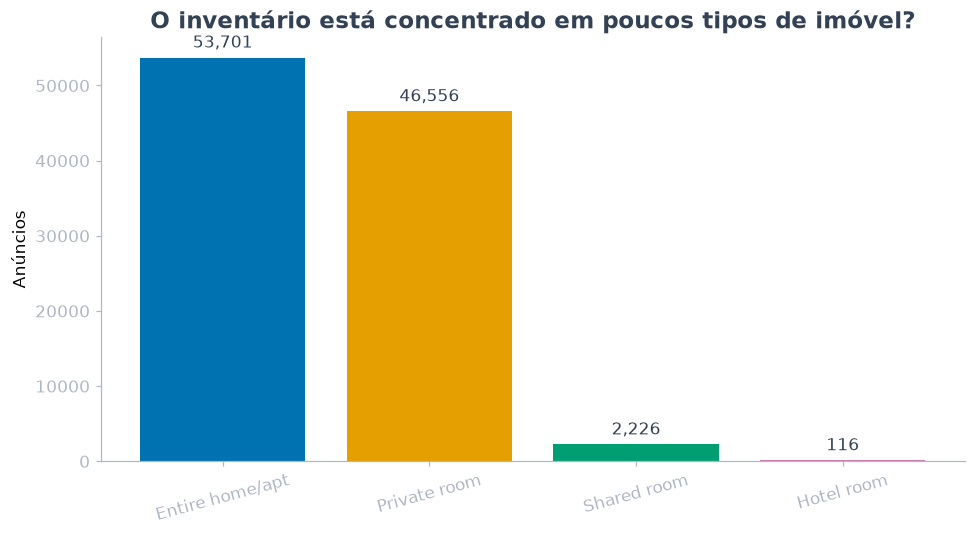

In [8]:
room_counts = df["room type"].fillna("Não informado").value_counts()
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(room_counts.index, room_counts.values, color=PALETA[:len(room_counts)])
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in room_counts.values], padding=4, fmt="%s")
ax.set_title("O inventário está concentrado em poucos tipos de imóvel?")
ax.set_ylabel("Anúncios")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()

**Resultado:** apartamentos/casas inteiros e quartos privados concentram quase todo o inventário. Operações podem começar por esses dois fluxos, mantendo hotel e quarto compartilhado como nichos menores.

## O preço mediano muda de forma consistente entre os tipos?
Uso a mediana para reduzir a influência de valores extremos e mostro também o número de anúncios.

room type,anuncios,preco_mediano
Private room,46556,"R$ 623,00"
Entire home/apt,53701,"R$ 624,00"
Hotel room,116,"R$ 644,50"
Shared room,2226,"R$ 651,00"


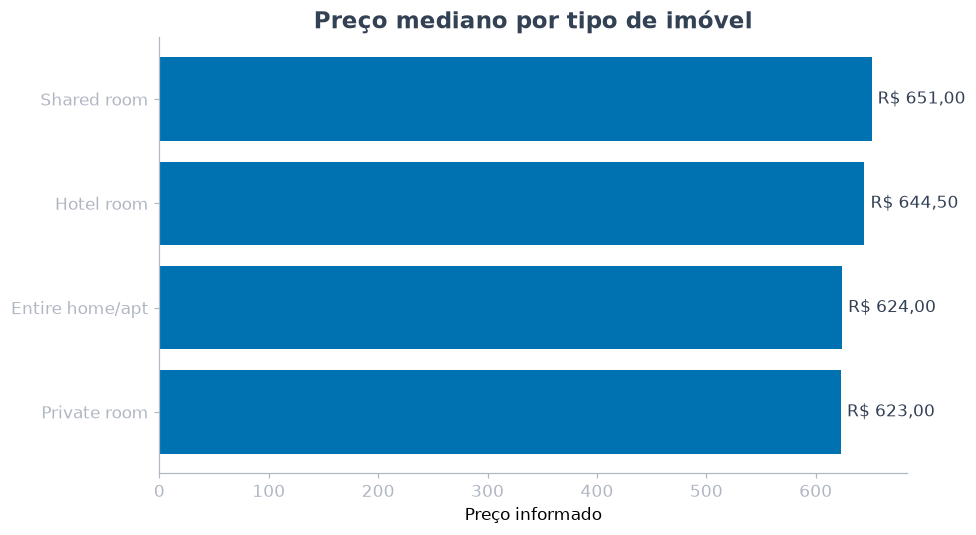

In [9]:
price_room = (df.groupby("room type", dropna=False).agg(anuncios=("id", "size"), preco_mediano=("price_num", "median"))
              .sort_values("preco_mediano", ascending=True).reset_index())
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(price_room["room type"].fillna("Não informado"), price_room["preco_mediano"], color=COR_PRIMARIA)
ax.bar_label(bars, labels=[reais(v) for v in price_room["preco_mediano"]], padding=4)
ax.set_title("Preço mediano por tipo de imóvel")
ax.set_xlabel("Preço informado")
plt.tight_layout()
display(price_room.style.format({"preco_mediano": reais}).hide(axis="index"))

**Resultado:** as medianas são muito próximas entre os tipos, um sinal atípico para uma leitura de mercado. Como os preços têm distribuição limitada e a fonte possui outras inconsistências, esta comparação deve ser tratada como diagnóstico da base, não como referência de precificação.

## Onde está concentrado o volume operacional?
A distribuição por grupo de vizinhança ajuda a priorizar cobertura e monitoramento.

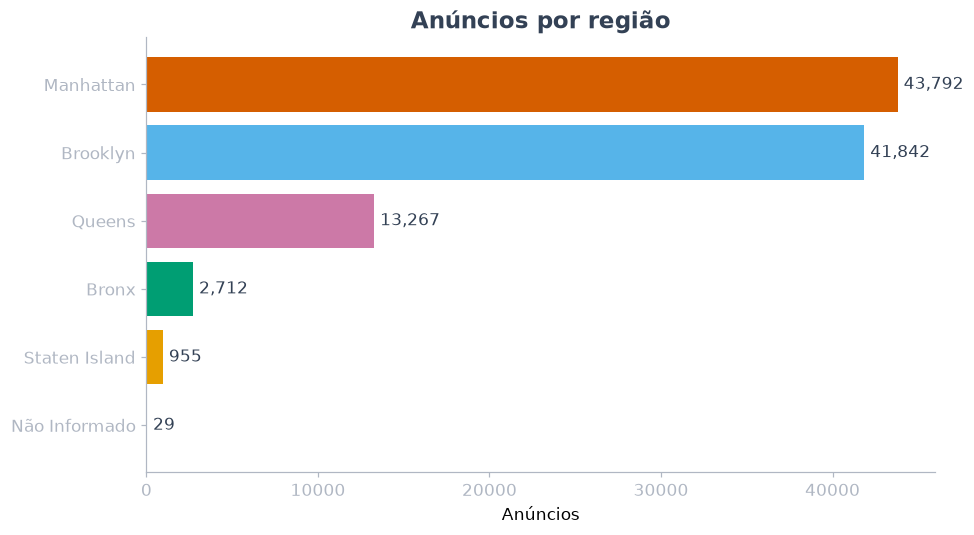

In [10]:
borough = (df["neighbourhood group"].fillna("Não informado").str.title().value_counts().head(6).sort_values())
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(borough.index, borough.values, color=PALETA[:len(borough)])
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in borough.values], padding=4)
ax.set_title("Anúncios por região")
ax.set_xlabel("Anúncios")
plt.tight_layout()

**Resultado:** Manhattan e Brooklyn formam o núcleo do volume, seguidos por Queens. Esse recorte é adequado para organizar rotinas operacionais por região, mas não mede demanda ou ocupação.

## Quantos dias estão disponíveis para reserva?
Vou separar faixas operacionais e marcar valores inválidos para não confundir ausência de disponibilidade com erro de cadastro.

anuncios
23544
10460
30641
34292
3662


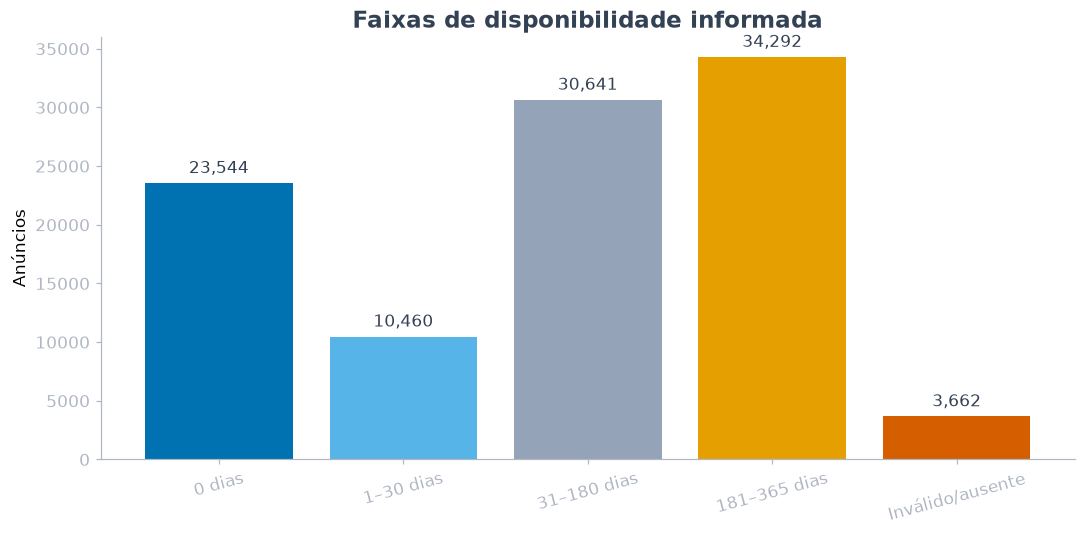

In [11]:
availability = df["availability 365"]
def faixa(v):
    if pd.isna(v) or v < 0 or v > 365: return "Inválido/ausente"
    if v == 0: return "0 dias"
    if v <= 30: return "1–30 dias"
    if v <= 180: return "31–180 dias"
    return "181–365 dias"
faixas = availability.map(faixa).value_counts().reindex(["0 dias", "1–30 dias", "31–180 dias", "181–365 dias", "Inválido/ausente"]).fillna(0)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(faixas.index, faixas.values, color=[COR_PRIMARIA, "#56B4E9", COR_SECUNDARIA, COR_DESTAQUE, "#D55E00"])
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in faixas.values], padding=4)
ax.set_title("Faixas de disponibilidade informada")
ax.set_ylabel("Anúncios")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
display(faixas.to_frame("anuncios").style.hide(axis="index"))

**Resultado:** a disponibilidade é útil para separar inventário pronto, restrito ou aberto, mas os valores inválidos precisam ser corrigidos antes de qualquer indicador de capacidade.

## Quais regiões e tipos merecem atenção operacional?
A tabela final combina volume, preço, disponibilidade e avaliações em um recorte consultável.

In [12]:
operacional = (df.assign(regiao=df["neighbourhood group"].fillna("Não informado"), tipo=df["room type"].fillna("Não informado"))
    .groupby(["regiao", "tipo"])
    .agg(anuncios=("id", "size"), preco_mediano=("price_num", "median"), disponibilidade_mediana=("availability 365", "median"), avaliacoes_mediana=("number of reviews", "median"))
    .sort_values("anuncios", ascending=False).head(12).reset_index())
display(operacional.style.format({"preco_mediano": reais, "disponibilidade_mediana": "{:,.0f}", "avaliacoes_mediana": "{:,.0f}"}).hide(axis="index"))

regiao,tipo,anuncios,preco_mediano,disponibilidade_mediana,avaliacoes_mediana
Manhattan,Entire home/apt,26473,"R$ 622,00",123,5
Brooklyn,Entire home/apt,20575,"R$ 626,00",87,10
Brooklyn,Private room,20434,"R$ 624,00",78,6
Manhattan,Private room,16312,"R$ 619,00",83,7
Queens,Private room,7751,"R$ 629,00",142,10
Queens,Entire home/apt,5146,"R$ 624,00",139,14
Bronx,Private room,1573,"R$ 652,00",174,11
Bronx,Entire home/apt,1022,"R$ 613,00",167,16
Manhattan,Shared room,907,"R$ 640,50",90,8
Brooklyn,Shared room,825,"R$ 662,00",170,3


A tabela é um ponto de partida para a operação: ela permite priorizar combinações com maior volume e comparar disponibilidade e interação. Ela não deve ser interpretada como rentabilidade ou ocupação, porque a fonte não traz reservas, receita realizada nem calendário confiável.

## O que a análise preliminar sustenta?

- O inventário é grande e concentrado em imóveis inteiros e quartos privados, com maior volume em Manhattan e Brooklyn.
- A disponibilidade pode apoiar uma rotina operacional, mas precisa de regras para valores fora de `0–365` e ausentes.
- Preços muito semelhantes entre categorias, datas futuras e duplicidades reduzem a confiabilidade para precificação.
- A próxima etapa recomendada é saneamento da fonte e definição de uma decisão operacional específica, como priorização de anúncios, disponibilidade ou qualidade do cadastro.

**Limite:** esta análise descreve anúncios, não reservas efetivas, ocupação, receita, conversão ou causalidade.